## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenarios

In [3]:
# Create session
session = cm.Session(
    name = 'FORMAS', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)
# cm.ParameterRetriever.data_path_scenarios = os.path.join('scenarios')

# Define scenarios

session.add_scenario(
    name = 'baseline',
    scenario_workbooks = None, 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'steers',
    scenario_workbooks = ['sng_area', 'steers'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'retired cows',
    scenario_workbooks = ['sng_area', 'ret_cows'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'winter lambs',
    scenario_workbooks = ['sng_area', 'wint_lamb'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'breeding horses',
    scenario_workbooks = ['sng_area', 'breeding_horses'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'all combined',
    scenario_workbooks = ['sng_area', 'steers', 'ret_cows', 'wint_lamb', 'breeding_horses'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)

A scenario with the name 'baseline' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'cur' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'steers' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'retired cows' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'winter lambs' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'all combined' already exists use .update_scenario() or .remove_scenario() instead.


## Plot results

In [7]:
# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '100' if '100' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : '',
    '70' : '-30% CH4',
    '100' : '+/-0% CH4',
    '110' : '+10% CH4'
}

### Bars: Main results

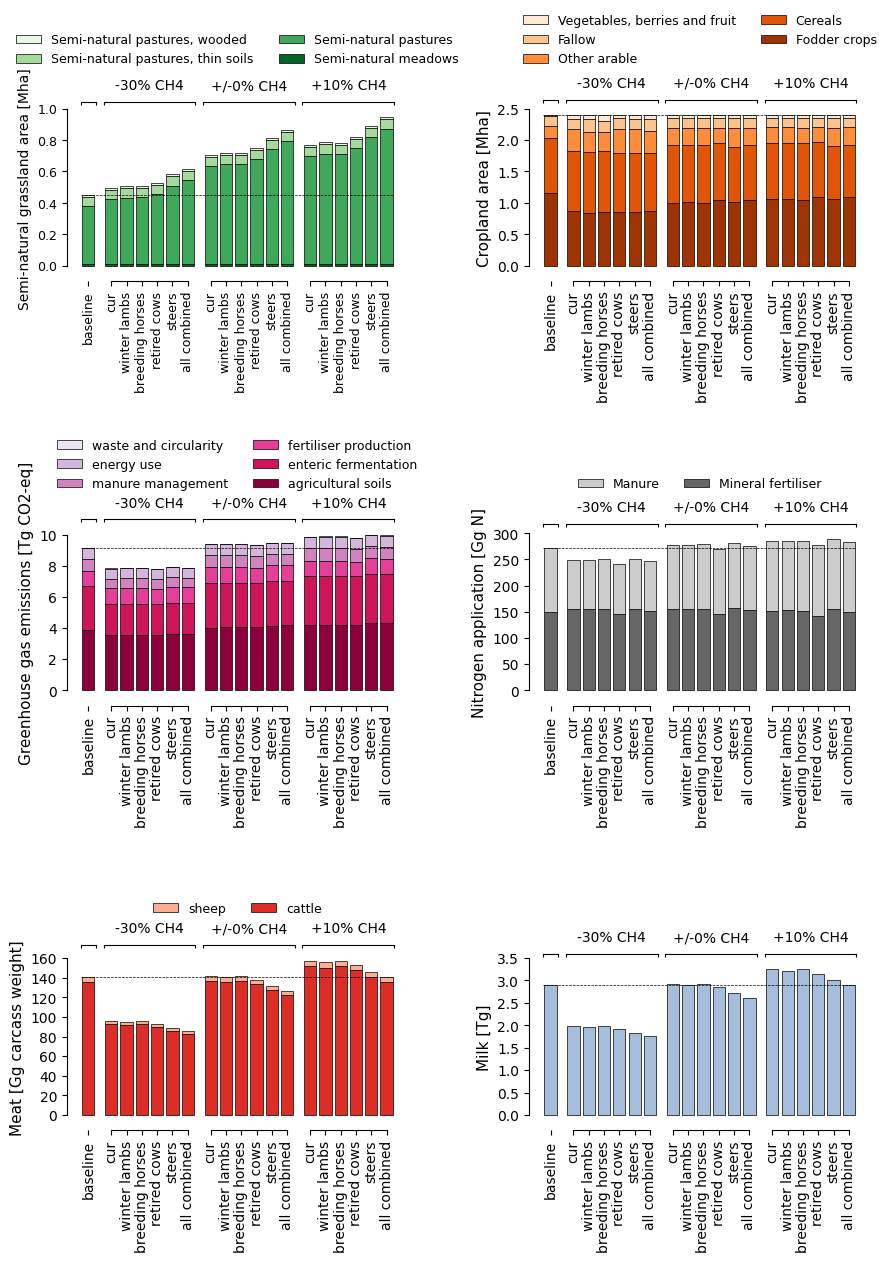

In [8]:
fig, axs = plt.subplots(3,2, figsize=(9,13))

# SNG AREA ---------------------------------------------------------------------- ##

ax=axs[0,0]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
)/1000000
sort = plot_data.sum(axis=1).sort_values().index

cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap='Greens',
    ylabel='Semi-natural grassland area [Mha]',
    ylabel_fontsize=10,
    grouplabels_fontsize=10,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

# CROP AREA ---------------------------------------------------------------------- ##

ax = axs[0,1]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[:,'cropland']
    .rename(rename_years)
)/1000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='Oranges',
    ylabel='Cropland area [Mha]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

# GHG ---------------------------------------------------------------------- ##

ax = axs[1,0]
plot_data = (
    cm.get_GHG(session, CO2eq = True)
    .T.groupby('process').sum().T
    .rename(rename_years)
)/1000000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='PuRd',
    ylabel='Greenhouse gas emissions [Tg CO2-eq]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

# N FERTILISER ---------------------------------------------------------------------- ##

ax = axs[1,1]
plot_data = (
    pd.concat([
        session.get_attr('c','fertiliser.mineral_N', 'none').rename('Mineral fertiliser'),
        session.get_attr('c','fertiliser.manure_N', 'none').rename('Manure')
    ], axis=1)
    .rename(rename_years)
)/1000000
from matplotlib.colors import ListedColormap
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#666666','#cccccc']),
    ylabel='Nitrogen application [Gg N]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

# MEAT AND MILK ---------------------------------------------------------------------- ##

plot_data = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
)/1000000
ax = axs[2,0]
cm.plot.bar(
    plot_data.loc[:,'meat'].loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fcae91']),
    ylabel='Meat [Gg carcass weight]'
)
ax.axhline(plot_data.loc[('baseline',''),'meat'].sum(), c='black', linewidth=0.5, linestyle='--')
ax = axs[2,1]
cm.plot.bar(
    plot_data.loc[:,'milk'].loc[sort]/1000,
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#a6bddb']),
    ylabel='Milk [Tg]'
)
ax.axhline(plot_data.loc[('baseline',''),'milk'].sum()/1000, c='black', linewidth=0.5, linestyle='--')

for ax in axs.flatten()[:-1]:
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1.2), frameon=False, ncol=2, fontsize=9, reverse=True)

plt.tight_layout()
plt.show()

### Bars: Grazing

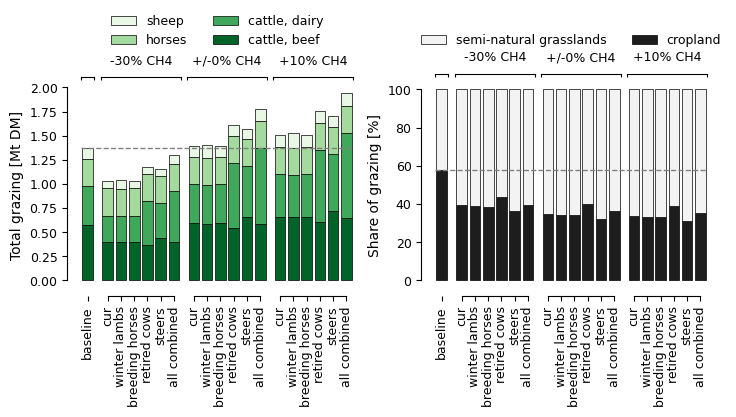

In [9]:
d1 = (
    session
    .get_attr('a','feed.crop_product_demand',['crop_prod','species','breed'])
    .loc[:,'grazing']
    .rename(rename_years)
    .loc[sort]
    /1_000_000_000
)
d1.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in d1.columns], name='animal_system')
d1 = d1.T.groupby('animal_system').sum().T

d2 = (
    session
    .get_attr('c','production',{'crop_prod':None, 'crop':'land_use'})
    .loc[:,'grazing']
    .apply(lambda x: x/x.sum()*100, axis=1)
    .rename(rename_years)
    .loc[sort]
)

fig,axs = plt.subplots(1,2, figsize=(7.5,4.5))
ax = axs[0]
cm.plot.bar(
    d1,
    group_levels='year',
    cmap='Greens',
    ylabel='Total grazing [Mt DM]',
    ylabel_fontsize=10,
    ticklabels_fontsize=9,
    grouplabels_fontsize=9,
    ax=ax
)
ax.axhline(y=d1.sum(axis=1).loc['baseline'].iloc[0], linestyle='--', linewidth=1, color='grey')

ax = axs[1]
cm.plot.bar(
    d2,
    group_levels='year',
    cmap='Greys',
    ylabel='Share of grazing [%]',
    ylabel_fontsize=10,
    ticklabels_fontsize=9,
    grouplabels_fontsize=9,
    ax=ax
)
ax.axhline(y=d2.loc['baseline','cropland'].iloc[0], linestyle='--', linewidth=1, color='grey')

for ax in axs.flatten():
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1.15), frameon=False, ncol=2, fontsize=9, reverse=True)

plt.tight_layout()
plt.show()

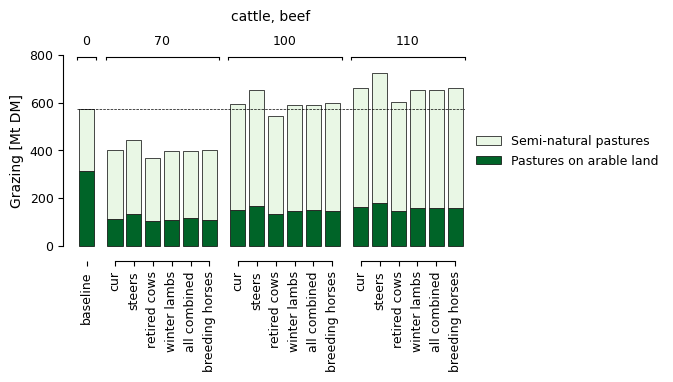

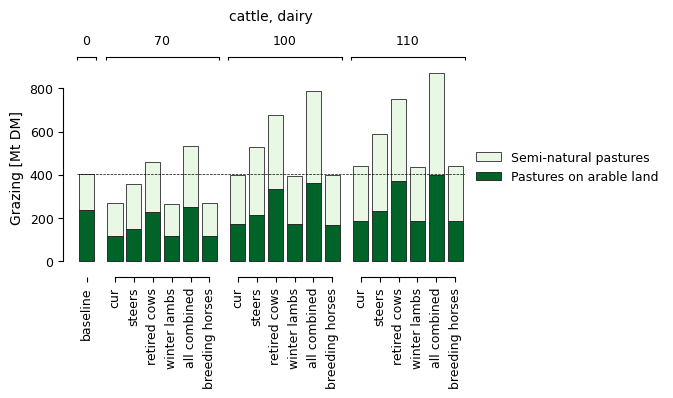

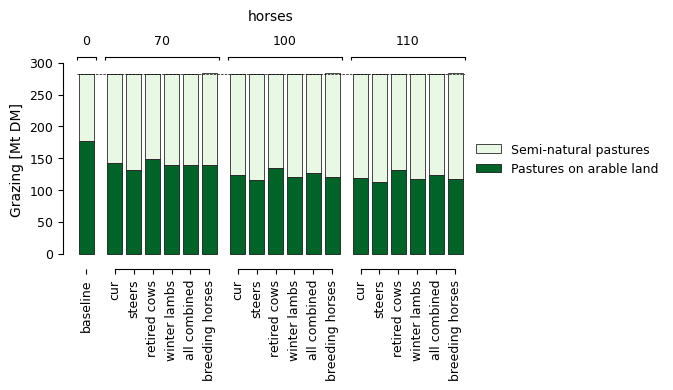

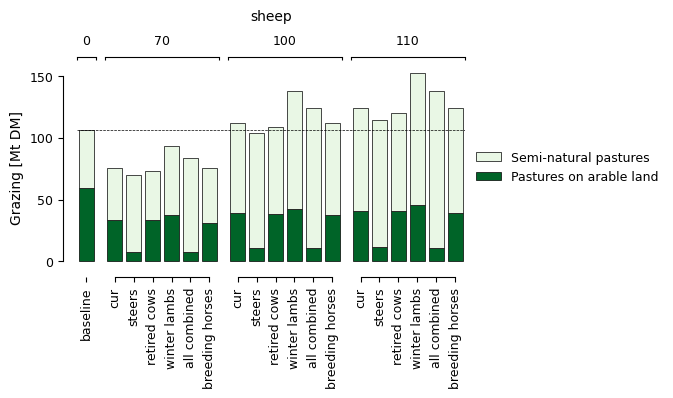

In [57]:
rename_crp = {
    'Ley for grazing' : 'Pastures on arable land',
    'Semi-natural pastures' : 'Semi-natural pastures',
    'Semi-natural pastures, thin soils' : 'Semi-natural pastures',
    'Semi-natural pastures, wooded' : 'Semi-natural pastures'
}

plot_data = (
    session.get_attr('c','production_per_use', ['crop', 'demand'])
    .loc[:,list(rename_crp)]
    .rename(columns=rename_crp, level='crop')
    .rename(
        columns=lambda x:
            'cattle, dairy' if 'cattle, dairy' in x else
            'cattle, beef' if 'cattle, beef' in x else
            'sheep' if 'sheep' in x else
            'horses' if 'horses' in x else
            '',
        level='demand'
    )
    .T.groupby(['crop','demand']).sum().T
    .rename_axis(columns={'demand':'animal_system'})
    .stack('animal_system') 
)/1_000_000

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='Greens'
    )
    ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

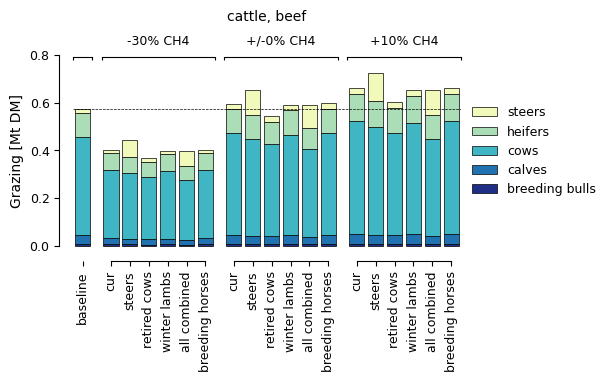

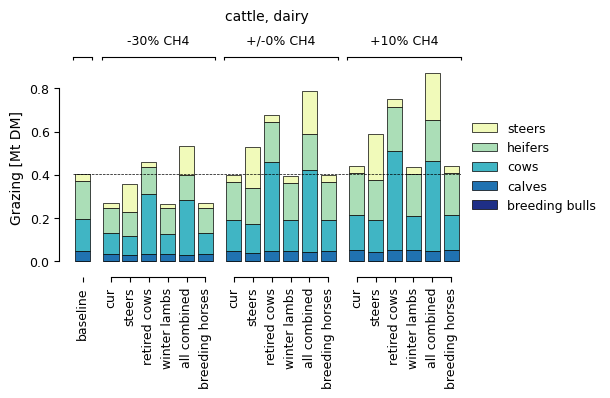

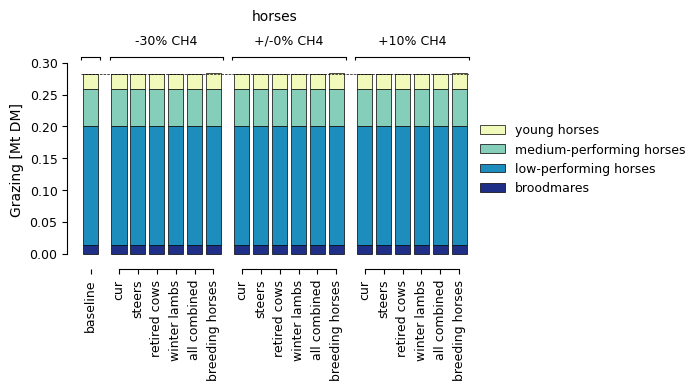

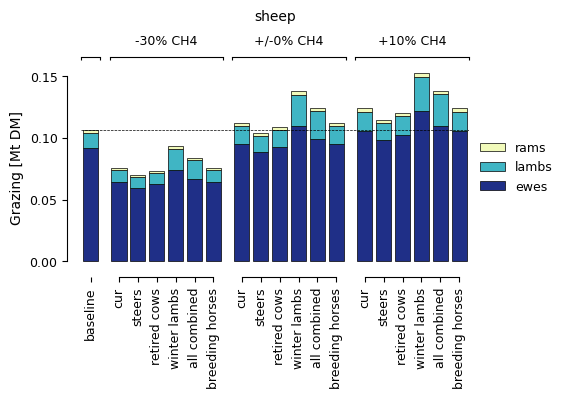

In [58]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .rename(rename_years)
    .loc[:,'domestic']
    .loc[:,'grazing']
    .stack(['species','breed'])
)/1_000_000_000
plot_data.index = pd.MultiIndex.from_tuples(
    [( scn, y, sp if sp != 'cattle' else ', '.join([sp,br]) ) for scn,y,sp,br in plot_data.index],
    names = ['scn', 'year', 'animal_system']
)
plot_data = plot_data.groupby(['scn', 'year', 'animal_system'], sort=False).sum()

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='YlGnBu'
    )
    ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

### Maps: Potential pastures and yield

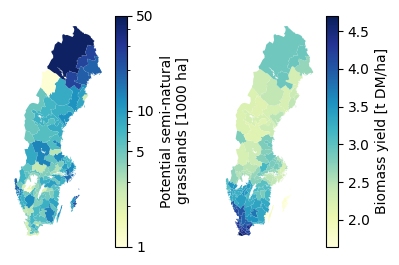

In [12]:
import matplotlib

a0 = session.get_attr('r','x0_crops',{'crop':'land_use', 'region':None}).loc[('baseline','0'), 'semi-natural grasslands']/1000
a1 = session.get_attr('r','x0_crops',{'crop':'land_use', 'region':None}).loc[('cur','100'), 'semi-natural grasslands']/1000
y = (
    (session.get_attr('c','harvest',{'crop':'land_use','region':None})
    /session.get_attr('c','area',{'crop':'land_use','region':None}))
    .loc[('baseline','0'),'semi-natural grasslands']
)/1000

fig, axs = plt.subplots(1,2, figsize=(5,3))
ax = axs[0]
cm.plot.map_from_series(a1-a0, cmap='YlGnBu', norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Potential semi-natural\ngrasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
ax.axis('off')

ax=axs[1]
cm.plot.map_from_series(y, cmap='YlGnBu', ax=ax, legend=False)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biomass yield [t DM/ha]', fontsize=10)
ax.axis('off')

plt.tight_layout
plt.show()

### Maps: Changes in semi-natural grassland and cropland area

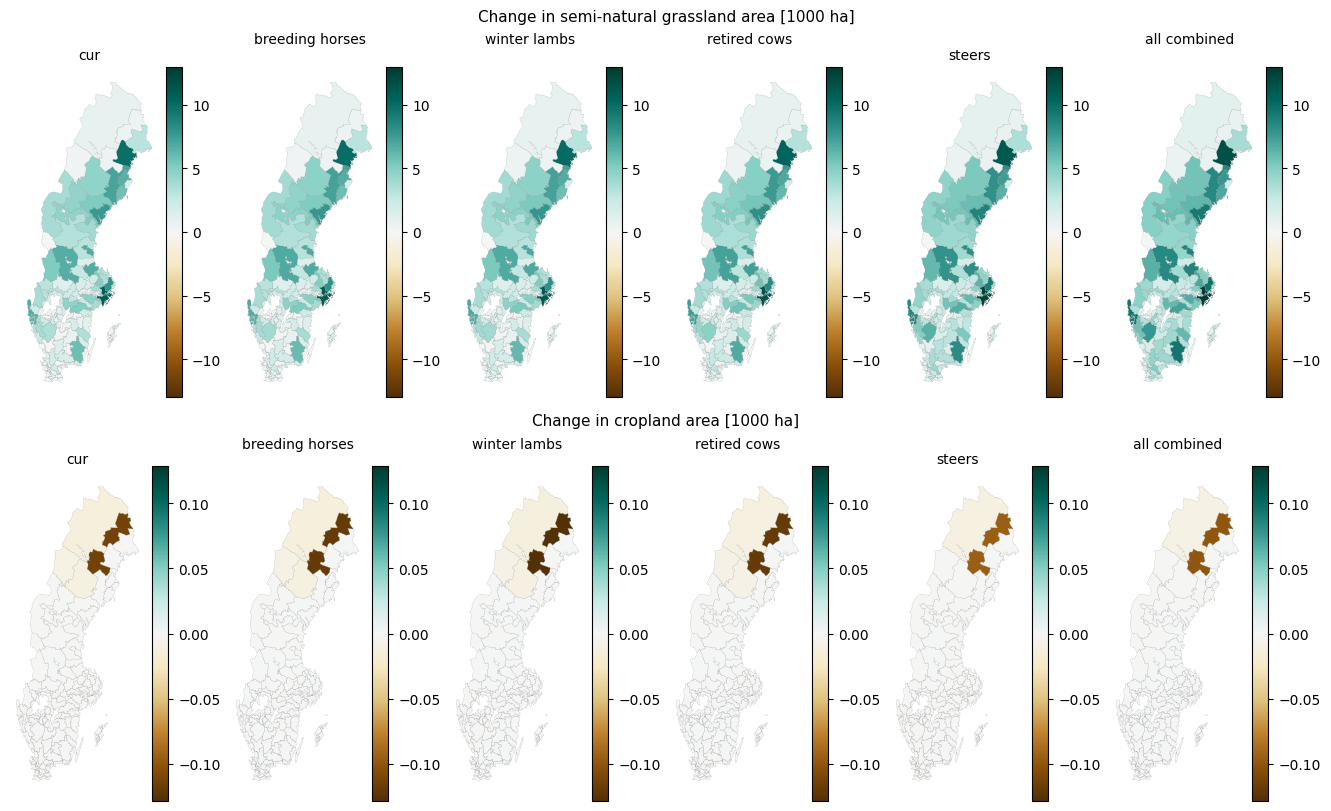

In [13]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('baseline','0')],axis=1))
    .drop(('baseline','0'))
    .droplevel('year')
)/1000

scn_sorted = plot_data.sum(axis=1).sort_values().index

n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

fig = plt.figure(layout='constrained', figsize=(2.2*n_scn, 8))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        vmin=-lims.loc['semi-natural grasslands'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        vmin=-lims.loc['cropland'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)

# fig.tight_layout()
plt.show()

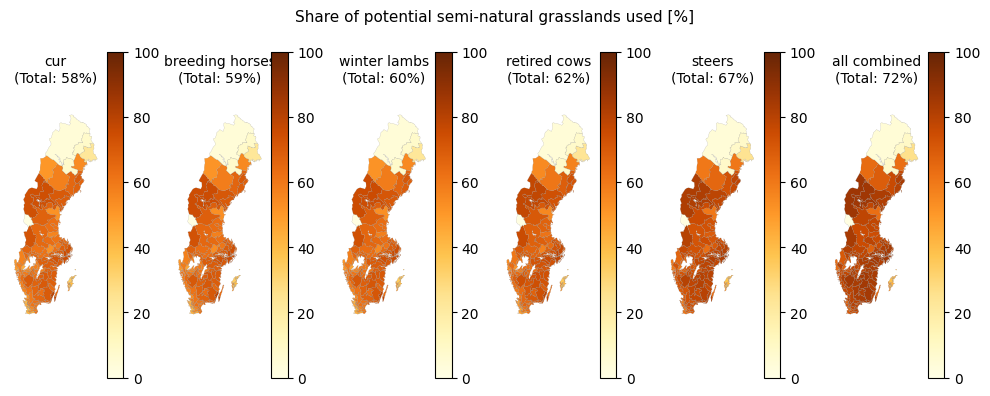

In [14]:
sng_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[scn_final,'semi-natural grasslands']
sng_pot = session.get_attr('r','max_land_use',['land_use','region']).loc[scn_final,'semi-natural grasslands']
tot_share = (sng_use.sum(axis=1) / sng_pot.sum(axis=1)).droplevel('year')*100

plot_data = (
    (sng_use / sng_pot)
    .drop('baseline', level='scn')
    .droplevel('year')
) * 100
scn_sorted = plot_data.sum(axis=1).sort_values().index

fig, axs = plt.subplots(1,len(plot_data), figsize=(10,4))
for n, scn in enumerate(scn_sorted):
    ax = axs[n]
    cm.plot.map_from_series(
        plot_data.loc[scn],
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of potential semi-natural grasslands used [%]', size=11)
plt.tight_layout()
plt.show()

### Maps. Changes in animal herds

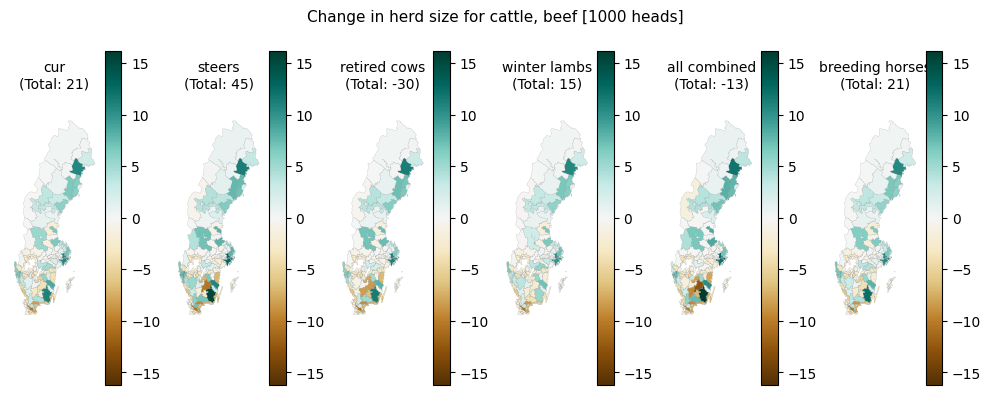

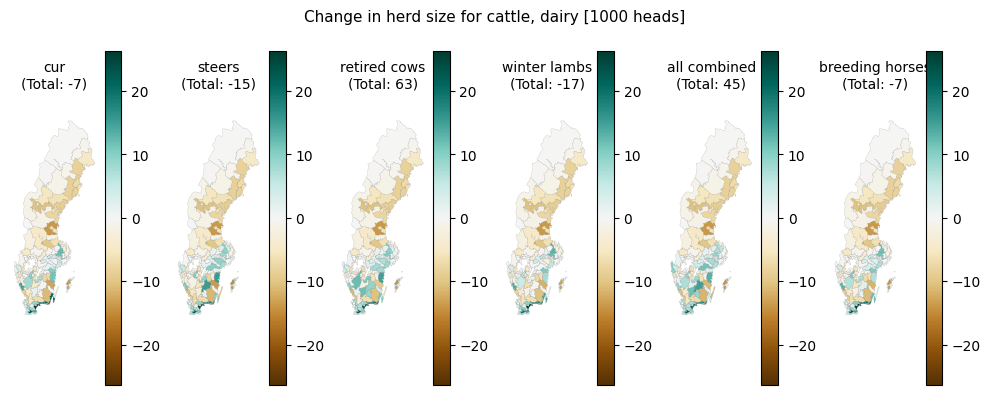

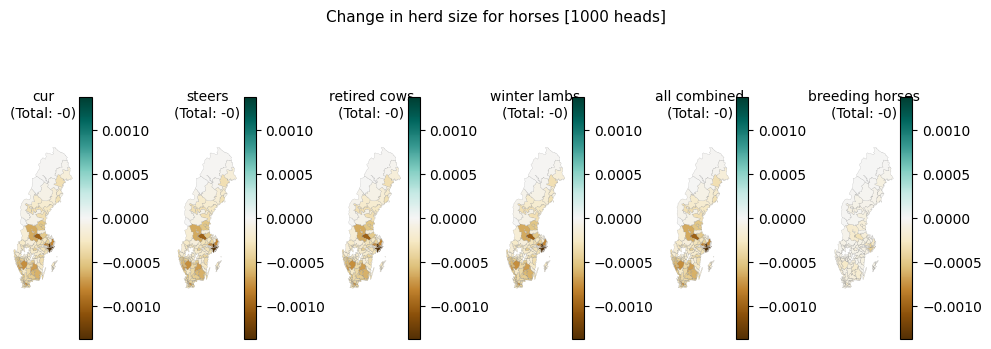

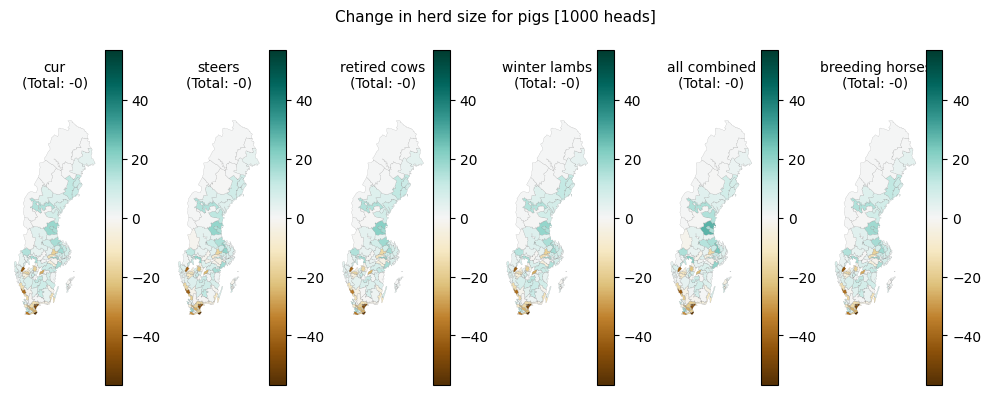

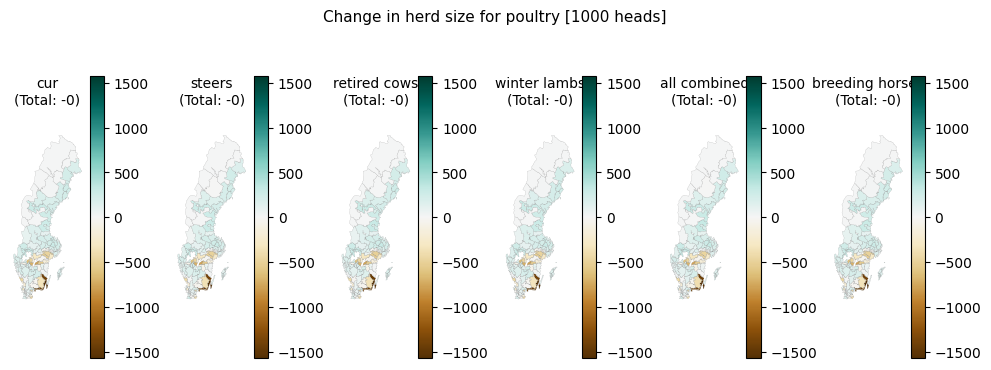

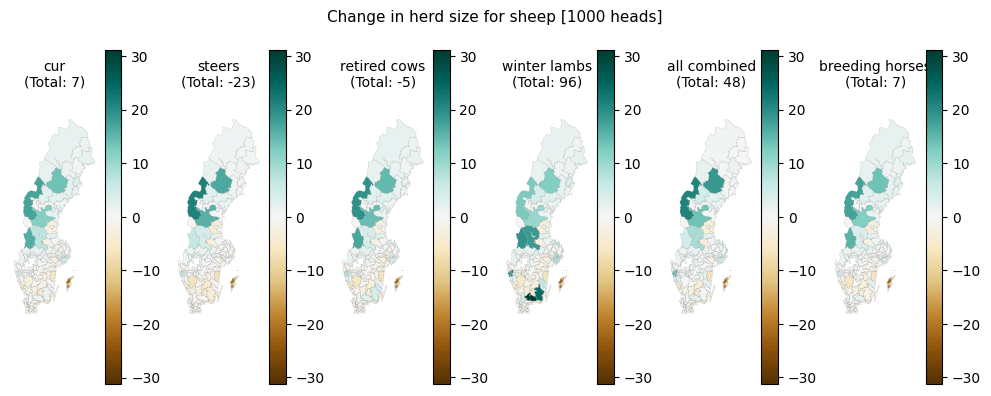

In [15]:
plot_data = (
    session.get_attr('a','heads',['region','species','breed'])
    .loc[scn_final]
    .droplevel('year')
    .transform(lambda x: x.sub(x.loc[('baseline')],axis=1))
    .drop('baseline')
    .stack('region')
)/1000
plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
plot_data = plot_data.T.groupby('animal_system').sum().T



for ani in plot_data.columns:
    d = plot_data.loc[:,ani]

    lim = max(-min(d.values), max(d.values))
    
    fig, axs = plt.subplots(1,len(d.index.unique('scn')), figsize=(10,4))
    for n, scn in enumerate(d.index.unique('scn')):
        ax = axs[n]
        cm.plot.map_from_series(
            d.loc[scn],
            ax = ax,
            vmin = -lim,
            vmax = lim,
            **map_style_div
        )
        ax.set_title(f'{scn}\n(Total: {d.loc[scn].sum():.0f})', size=10)
        ax.axis('off')
    fig.suptitle(f'Change in herd size for {ani} [1000 heads]', size=11)
    plt.tight_layout()
    plt.show()

## Run scenarios (multi proc.)

In [59]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

In [60]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('all')]
runs

[('baseline', '0'),
 ('cur', '70'),
 ('cur', '100'),
 ('cur', '110'),
 ('steers', '70'),
 ('steers', '100'),
 ('steers', '110'),
 ('retired cows', '70'),
 ('retired cows', '100'),
 ('retired cows', '110'),
 ('winter lambs', '70'),
 ('winter lambs', '100'),
 ('winter lambs', '110'),
 ('all combined', '70'),
 ('all combined', '100'),
 ('all combined', '110'),
 ('breeding horses', '70'),
 ('breeding horses', '100'),
 ('breeding horses', '110')]

In [ ]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
            
session.cache.clear()

## Run scenarios here

In [49]:
import sys
import os
import time
from contextlib import redirect_stdout, redirect_stderr
import numpy as np
import scipy
import cvxpy
import matplotlib.pyplot as plt
sys.path.insert(0, 'C:/Users/jnka0003/Git repos/CIBUSmod')
import CIBUSmod as cm
from CIBUSmod.utils.helpers import check_constraints

In [50]:
# Create session (Make sure that name and data_path match the notebook!)
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
    timeout = 60 # Increase timeout to avoid failing to write if multiple processes try to write at the same time
)

In [51]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions'),
    settings = {'max_land_use_from_scenario_x0' : True}
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [55]:
feed_mgmt.par.update_parameter_values(scenario_workbooks='breeding_horses', year=0)
feed_mgmt.par.data.xs('max_crop_in_crop_prod', level='parameter')

f_species  f_breed        f_prod_system  f_sub_system  f_animal      f_feed  f_crop_group           f_crop_prod  f_by_prod  f_crop_resid  f_region
cattle     NaN            NaN            NaN           NaN           NaN     Semi-natural pastures  grazing      NaN        NaN           NaN          85.0
           dairy          NaN            NaN           cows          NaN     Semi-natural pastures  grazing      NaN        NaN           NaN          20.0
horses     NaN            NaN            NaN           NaN           NaN     Semi-natural pastures  grazing      NaN        NaN           NaN          14.5
sheep      NaN            NaN            NaN           NaN           NaN     Semi-natural pastures  grazing      NaN        NaN           NaN         100.0
                                         autumn lamb   lambs         NaN     Semi-natural pastures  grazing      NaN        NaN           NaN          69.0
horses     riding horses  NaN            NaN           broodmares    NaN 

In [9]:
def _max_sng_obj(geodist):
    geodist.define_cvx_problem()

    # Get x variable
    x = geodist.problem.variables()[0]

    # Create objective
    rel = cm.ParameterRetriever.get_rel('crop','land_use')
    P = np.concatenate([
        np.zeros(len(geodist.x_idx_short['ani'])),
        np.array([1 if rel[cr] == 'semi-natural grasslands' else 0 for cr,_,_ in geodist.x_idx_short['crp']])
    ])
    obj = cvxpy.Maximize(
        cvxpy.sum(cvxpy.multiply(P, x))
    )
    
    # Create problem
    geodist.problem = cvxpy.Problem(
        objective = obj,
        constraints = geodist.problem.constraints
    )

In [10]:
def _make_ani_cons(geodist, name, M, b, rel):
    
    from CIBUSmod.optimisation.geo_dist import IndexedMatrix
    
    # Create A matrix
    M = scipy.sparse.csc_matrix(M)
    Z = scipy.sparse.csc_matrix((M.shape[0],len(geodist.x_idx_short['crp']))) # Zero matrix
    A = scipy.sparse.hstack([M,Z], format='csc')
    A = IndexedMatrix(
        matrix=A,
        row_idx=pd.Index([name]),
        col_idx={k:v.copy() for k,v in geodist.x_idx_short.items()}
    )
    
    # Append constraint
    geodist.constraints.update({f'{name}: A @ x {rel} b' : {
        'left' : lambda x,A: A.M @ x,
        'right' : lambda A: b,
        'rel' : rel,
        'pars' : {'A':A}
    }})

    return None

In [11]:
def _get_herds_par(herds, attr):
    
    res = pd.concat([
        pd.concat({h.species: 
            pd.concat({h.breed:
                pd.concat({h.prod_system:
                    pd.concat({h.sub_system:
                        h.data_attr.get(attr)
                    }, names=['sub_system'])
                }, names=['prod_system'])
            }, names=['breed'])
        }, names=['species'])
    for h in herds])

    return res

In [12]:
def _make_CH4_cons(geodist, feed_mgmt, baseline_CH4, factor):
    
    feed_mgmt.calculate2()
    
    # Get CH4 emissions per defining animal
    CH4 = _get_herds_par(herds, 'enteric_methane').sum(axis=1).reindex(geodist.x_idx_short['ani'])
    
    # Assert that indexes match
    assert (CH4.index == geodist.x_idx_short['ani']).all()
    
    _make_ani_cons(geodist, name='CH4', M=CH4, b=baseline_CH4 * factor, rel='<=')

    return None

In [13]:
def _make_milkmeat_cons(geodist, baseline_milkmeat):

    # Get milk and meat prod. per defining animal
    meat = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milk = _get_herds_par(herds, 'production').xs('milk', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milkmeat = (milk - meat*baseline_milkmeat)
    _make_ani_cons(geodist, name='milk/meat', M=milkmeat, b=0, rel='==')

    return None

In [14]:
def _make_beeflamb_cons(geodist, baseline_beeflamb):

    # Get beef and lamb prod. per defining animal
    beef = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    lamb = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('sheep', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    beeflamb = (beef - lamb*baseline_beeflamb)
    _make_ani_cons(geodist, name='beef/lamb', M=beeflamb, b=0, rel='==')

    return None

In [15]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('cur')]
runs

[('cur', '70'), ('cur', '100'), ('cur', '110')]

In [ ]:
for scn, year in runs:
    
    tic = time.time()
    scn_str = f'Scenario: {scn}, {year}'
    print(f'\n{"-"*len(scn_str)}\n{scn_str}\n{"-"*len(scn_str)}\n')
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year = year
    )
    
    # Get region attributes
    regions.calculate(verbose=True)
    
    # Calculate food demand
    demand.calculate(verbose=True)
    
    # Calculate crops
    crops.calculate(verbose=True)
    
    # Calculate herds
    for h in herds:
        h.calculate(verbose=True)
    
    # Calculate feed
    feed_mgmt.calculate(verbose=True)
    
    if scn != 'baseline':
        while True:
            try:
                # Get baseline crop areas, animal numbers and land use
                baseline_ani = session.get_attr('geo','x_animals', scn='baseline').iloc[0]
                baseline_crp = session.get_attr('geo','x_crops', scn='baseline').iloc[0]
                baseline_lu = session.get_attr('c','area',{'region':None, 'crop':'land_use'}, scn='baseline').iloc[0].unstack()
                # Get baseline CH4 emissions
                baseline_CH4 = session.get_attr(
                    'A', 'enteric_methane',
                    'none',
                    scn='baseline'
                ).iloc[0]
                # Get baseline milk/meat
                prod = session.get_attr('A', 'prod', ['species', 'animal_prod'], scn='baseline').iloc[0]
                baseline_milkmeat = prod[('cattle','milk')] / prod[('cattle','meat')]
                # Get baseline beef/lamb
                prod = session.get_attr('A', 'prod', ['species','animal_prod'], scn='baseline').iloc[0]
                baseline_beeflamb = prod[('cattle','meat')] / prod[('sheep','meat')]
            except:
                time.sleep(10)
            else:
                break
    
    # Distribute animals and crops
    # Make optimisation problem
    if scn == 'baseline':
        geodist.make(
            use_cons=[1,2,3,4,5,6,7],
            scale_power=0.4,
            verbose=True
        )
        # Solve optimisation problem
        geodist.solve(verbose=True)
    else:
        # Drop demand for cattle, sheep and horses
        demand.data_attr.update(
            'animal_prod_demand',
            demand.data_attr.get('animal_prod_demand')
            .loc[(slice(None),['pigs','poultry'],slice(None))]
        )
    
        # Set maximum cropland and greenhouse area to baseline levels
        regions.data_attr.get('max_land_use').update(baseline_lu.loc[:,['cropland','greenhouse']])
    
        # Baseline Semi-natural grassland areas
        C8_SNG_P = baseline_crp.copy()\
        .loc[['Semi-natural pastures']]
        C8_SNG_PWT = baseline_crp.copy()\
        .loc[['Semi-natural pastures, wooded','Semi-natural pastures, thin soils']]
        C8_SNG_M = baseline_crp.copy()\
        .loc[['Semi-natural meadows']]
        C8_FAL = baseline_crp.copy()\
        .loc[['Fallow', 'Ley not harvested']]# * 0.8
        C8_ani = baseline_ani.copy()
    
        geodist.make(
            use_cons=[1,2,3,4,5,6,7,8],
            scale_power=0.4,
            C8_crp = [ C8_SNG_P,   C8_SNG_PWT,   C8_SNG_M,   C8_FAL,   None                    ],
            C8_ani = [ None,       None,         None,       None,     C8_ani.loc[['horses']]  ],
            C8_rel = [ '>=',       '==',         '==',       '>=',     '=='                    ],
            verbose=True
        )
        
        # Add constraint on CH4 emissions and milk/meat
        CH4_factor = float(year)/100
        _make_CH4_cons(geodist, feed_mgmt, baseline_CH4, CH4_factor)
        _make_milkmeat_cons(geodist, baseline_milkmeat)
        _make_beeflamb_cons(geodist, baseline_beeflamb)
    
        # First we solve while dropping everything from the
        # obejctive except for semi-natural grasslands
        for w in ['ani','crp']:
            for k in geodist.x0_idx[w].unique(0):
                if k not in ['Semi-natural pastures', 'Semi-natural pastures, wooded', 'Semi-natural pastures, thin soils', 'Semi-natural meadows']:
                    cm.helpers.drop_from_objective(geodist, which=w, key=k)
        geodist.solve(apply_solution=False, verbose=True)
    
        # Get semi-natural grassland areas from first solution and add constraint on
        # semi-natural grassland area for second optimization round
        sng_areas = geodist.x['crp'].loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
        geodist.make_C8(C8_crp = sng_areas, C8_rel = '>=') 
        geodist.make_C7()
    
        # Solve optimisation problem again, this time minimising deviation from current
        # crop areas and animal numbers
        geodist.define_cvx_problem()
        geodist.solve(verbose=True)
    
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=True)
    
    # Balance by-product demand and suply
    byprod_mgmt.calculate(verbose=True)
    
    # Calculate manure
    manure_mgmt.calculate(verbose=True)
    
    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=True)
    
    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)
    
    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=True)
    
    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=True)
    
    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=True)
    
    # Store results (try again if first atempt fails)
    try:
        session.store(
            scn, year,
            demand, regions, crops, herds, waste, geodist
        )
    except:
        session.store(
            scn, year,
            demand, regions, crops, herds, waste, geodist
        )

    t = time.time() - tic
    m = int(t/60)
    s = int(round(t - m*60))
    print(f'{scn}, {year} finished successfully in {m}min {s}s')

    check_constraints(geodist)
    plt.show()